In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
import time

In [2]:
epochs = 50
noise_dim = 100
batch_size = 64
num_classes = 10

In [21]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Convert to float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Input images with a single channel
x_train, x_test = np.expand_dims(x_train, axis=-1), np.expand_dims(x_test, axis=-1)

# Normalize images value from [0, 255] to [0, 1].
x_train, x_test = x_train / 255., x_test / 255.

# Use tf.data API to shuffle and batch data.
buffer_size = x_train.shape[0]
train_data=tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data=train_data.shuffle(buffer_size).batch(batch_size).prefetch(1)

In [22]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(noise_dim * 2,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, 
                                     activation='tanh'))
    
    # takes noise of shape (noise_dim, ) and label of shape (1,) as inputs
    noise = layers.Input(shape=(noise_dim,))
    
    label = layers.Input(shape=(1,), dtype='int32')
    label_embedding = layers.Flatten()(layers.Embedding(num_classes, noise_dim)(label))

    model_input = layers.concatenate([noise, label_embedding])
    
    img = model(model_input)

    return tf.keras.Model([noise, label], img)

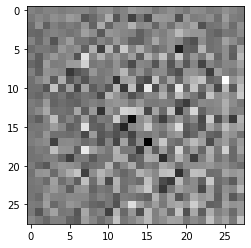

In [23]:
generator = make_generator_model()

noise = tf.random.normal([1, noise_dim])
label = tf.constant([[1]])
generated_image = generator([noise, label], training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

In [24]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    
    input_img = layers.Input(shape=(28, 28, 1))
    
    feature_vector = model(input_img)
    
    decision = layers.Dense(1)(feature_vector)
    class_pred = layers.Dense(num_classes)(feature_vector)
    
    return tf.keras.Model(input_img, [decision, class_pred])

In [25]:
discriminator = make_discriminator_model()
decision, class_pred = discriminator(generated_image, training=False)
print (decision, class_pred)

tf.Tensor([[-0.00060886]], shape=(1, 1), dtype=float32) tf.Tensor(
[[ 0.00162916  0.00143165 -0.00324604 -0.00119314  0.00017435  0.00373879
  -0.00094378  0.00061989  0.00111924  0.00239283]], shape=(1, 10), dtype=float32)


In [26]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# This method returns a helper function to compute cross entropy loss
class_cross_entropy = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [27]:
def discriminator_loss(real_output, real_class_pred, real_class_label, 
                       fake_output, fake_class_pred, fake_class_label):
    # discriminator loss
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    
    # auxiliary classifier loss
    real_class_loss = class_cross_entropy(real_class_label, real_class_pred)
    fake_class_loss = class_cross_entropy(fake_class_label, fake_class_pred)
    total_loss = real_loss + fake_loss + real_class_loss + fake_class_loss
    
    return total_loss

In [28]:
def generator_loss(fake_output, fake_class_pred, fake_class_label):
    inv_fake_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
    fake_class_loss = class_cross_entropy(fake_class_label, fake_class_pred)
    return inv_fake_loss + fake_class_loss

In [43]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images, labels):
    noise = tf.random.uniform(minval=-1., maxval=1., shape=[images.shape[0], noise_dim], dtype=tf.float32)
    random_labels = np.random.randint(0, 10, images.shape[0]).reshape(-1, 1)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # fake image and fake class
        generated_images = generator([noise, random_labels], training=True)
        fake_output, fake_class_pred = discriminator(generated_images, training=True)
        real_output, real_class_pred = discriminator(images, training=True)
        
        gen_loss = generator_loss(fake_output, fake_class_pred, random_labels)
        disc_loss = discriminator_loss(real_output, real_class_pred, labels,
                                       fake_output, fake_class_pred, random_labels)
        
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [44]:
def generate_and_save_images(model, epoch, test_input, test_label):
    # Notice `training` is set to False.
    # This is so all layers run in inference mode (batchnorm).
    predictions = model([test_input, test_label], training=False)

    fig = plt.figure(figsize=(10, 3))

    for i in range(predictions.shape[0]):
        plt.subplot(3, 10, i+1)
        plt.imshow(predictions[i, :, :, 0] * 255, cmap='gray')
        plt.axis('off')

    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

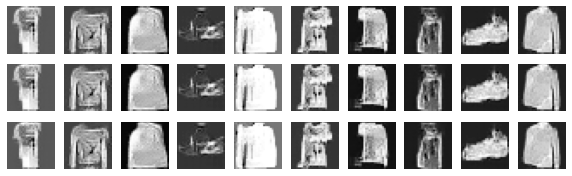

In [45]:
from IPython import display

seed_noise = tf.random.uniform(minval=-1, maxval=1, shape=[30, noise_dim], dtype=tf.float32)
seed_label = tf.constant(list(range(10)) * 3)

for epoch in range(epochs):
    start = time.time()

    for image_batch, label_batch in train_data:
        train_step(image_batch, label_batch)

    # Produce images for the GIF as you go
    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed_noise, seed_label)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

# Generate after the final epoch
display.clear_output(wait=True)
generate_and_save_images(generator,
                       epochs,
                       seed_noise, seed_label)

In [46]:
import glob
import imageio

anim_file = 'gan-acgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
    filenames = glob.glob('image_at_epoch_*.png')
    filenames = sorted(filenames)
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
    image = imageio.imread(filename)
    writer.append_data(image)

![](./gan-acgan.gif)